# Classical ML Models — Rain in Australia

This notebook trains and evaluates four classical ML models for predicting **RainTomorrow** (binary):
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

All model pipelines are defined in `classical_models.py`.  
Tuning & calibration utilities are in `hyperparameter_tuning.py`.

**Primary evaluation metric:** ROC-AUC (per cahier de charge).

## 1 — Imports & Constants

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import RocCurveDisplay
from classical_models import get_all_models, evaluate_model, FEATURE_COLUMNS, TARGET_RAIN
from hyperparameter_tuning import (
    get_param_grids, get_param_distributions,
    run_grid_search, run_random_search,
    run_optuna_study,
    calibrate_model, compare_calibration,
    plot_learning_curves, plot_calibration_curves,
)

from datetime import datetime 
from tqdm.auto import tqdm

DATA_PATH   = "data/clean_data.csv"
MODELS_DIR  = "saved_models/"
os.makedirs(MODELS_DIR, exist_ok=True)

def ts ():
    return datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

Imports OK


## 2 — Data Loading

In [11]:
# Load a small HEAD for schema validation only
df_schema = pd.read_csv(DATA_PATH, nrows=5)
print("Columns:", df_schema.columns.tolist())
print("Shape preview:", df_schema.shape)

# Full load (uncomment to train)
df = pd.read_csv(DATA_PATH)
X = df[FEATURE_COLUMNS]
y = df[TARGET_RAIN]
print(f"Full dataset: {X.shape}")
print(f"Rain prevalence: {y.mean():.2%}")

Columns: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow', 'Month', 'TempRange', 'Humidity_Avg', 'Pressure_Diff', 'WindDir3pm_sin', 'WindDir3pm_cos', 'City_Encoded', 'Month_sin', 'Month_cos']
Shape preview: (5, 28)
Full dataset: (145460, 21)
Rain prevalence: 21.91%


## 3 — Train / Test Split

In [ ]:
# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # Critical: preserve ~22% rain ratio
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Rain prevalence — Train: {y_train.mean():.2%}, Test: {y_test.mean():.2%}")

Train: (116368, 21), Test: (29092, 21)
Rain prevalence — Train: 21.91%, Test: 21.91%
Split logic ready — uncomment above cells to execute.


## 4 — Model Instantiation Check

In [13]:
# Verify all 4 models instantiate without error
models = get_all_models()
for name, pipeline in models.items():
    clf_name = type(pipeline.steps[-1][1]).__name__
    print(f"\u2705 {name}: {clf_name}")

✅ logistic_regression: LogisticRegression
✅ decision_tree: DecisionTreeClassifier
✅ random_forest: RandomForestClassifier
✅ xgboost: XGBClassifier


## 5 — Cross-Validation Setup

In [ ]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["roc_auc", "f1", "accuracy", "precision", "recall"]

cv_results = {}
for name, pipeline in models.items():
    print(f"\nRunning CV for {name}...")
    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv_strategy, scoring=scoring,
        n_jobs=-1, return_train_score=True
    )
    cv_results[name] = scores
    print(f"  ROC-AUC: {scores['test_roc_auc'].mean():.4f} \u00b1 {scores['test_roc_auc'].std():.4f}")
    print(f"  F1:      {scores['test_f1'].mean():.4f} \u00b1 {scores['test_f1'].std():.4f}")
    print(f"  Accuracy:{scores['test_accuracy'].mean():.4f} \u00b1 {scores['test_accuracy'].std():.4f}")


Running CV for logistic_regression...
  ROC-AUC: 0.8511 ± 0.0026
  F1:      0.5968 ± 0.0034
  Accuracy:0.7783 ± 0.0013

Running CV for decision_tree...
  ROC-AUC: 0.8440 ± 0.0015
  F1:      0.5906 ± 0.0008
  Accuracy:0.7733 ± 0.0030

Running CV for random_forest...
  ROC-AUC: 0.8732 ± 0.0020
  F1:      0.6345 ± 0.0026
  Accuracy:0.8158 ± 0.0008

Running CV for xgboost...


/home/limam/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:33:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/limam/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:33:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/limam/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:33:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/limam/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:33:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/limam/.local/lib/pytho

  ROC-AUC: 0.8801 ± 0.0025
  F1:      0.6404 ± 0.0042
  Accuracy:0.8111 ± 0.0019
CV strategy defined — uncomment above to run.


## 6 — Overfitting Monitoring: Learning Curves

Learning curves plot training vs validation scores for increasing training set sizes.  
A large gap between train and val scores indicates **overfitting**.

/home/limam/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:37:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/limam/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:37:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/limam/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:37:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/limam/.local/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:37:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/limam/.local/lib/pytho

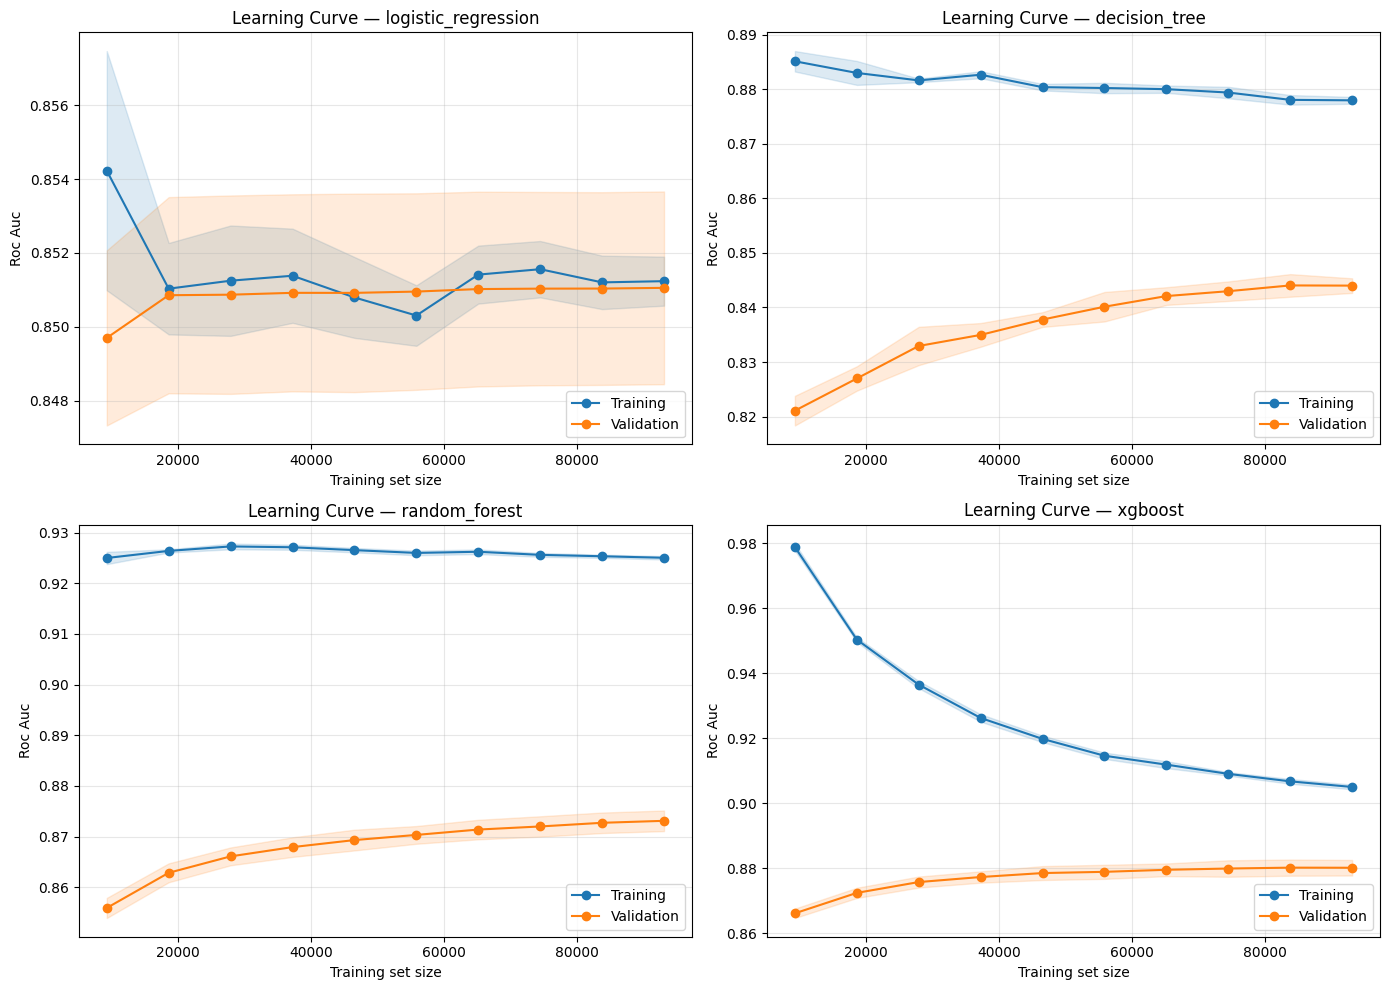

✅ Learning curves saved to artifacts/fig_learning_curves.png


In [ ]:
TRAINED = True

if TRAINED:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (name, pipeline) in zip(axes.flat, get_all_models().items()):
        plot_learning_curves(
            pipeline, X_train, y_train,
            cv=cv_strategy, scoring="roc_auc", ax=ax
        )
        ax.set_title(f"Learning Curve — {name}")
    plt.tight_layout()
    plt.savefig(f"artifacts/{ts()}_fig_learning_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\u2705 Learning curves saved to artifacts/fig_learning_curves.png")
else:
    print("\u23ed Skipping learning curves — set TRAINED=True after loading data.")

## 7 — Hyperparameter Tuning: GridSearchCV

In [ ]:
param_grids = get_param_grids()
print("Parameter grids defined:")

# Progress bar for counting combinations
for name, grid in tqdm(param_grids.items(), desc="Counting grid sizes"):
    n_combos = 1
    for v in grid.values():
        n_combos *= len(v)
    print(f"  {name}: {n_combos} combinations")

gs_results = {}

# Progress bar for models
for name, pipeline in tqdm(models.items(), desc="Running GridSearch"):
    print(f"\n{'='*60}")
    print(f"GridSearchCV: {name}")

    gs = run_grid_search(
        pipeline,
        param_grids[name],
        X_train,
        y_train,
        cv=cv_strategy
    )

    gs_results[name] = gs
    print(f"  Best ROC-AUC: {gs.best_score_:.4f}")
    print(f"  Best params:  {gs.best_params_}")

Parameter grids defined:
  logistic_regression: 8 combinations
  decision_tree: 36 combinations
  random_forest: 36 combinations
  xgboost: 81 combinations

GridSearchCV: logistic_regression
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  Best ROC-AUC: 0.8511
  Best params:  {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

GridSearchCV: decision_tree
Fitting 5 folds for each of 36 candidates, totalling 180 fits
  Best ROC-AUC: 0.8465
  Best params:  {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 100, 'classifier__min_samples_split': 2}

GridSearchCV: random_forest
Fitting 5 folds for each of 36 candidates, totalling 180 fits


## 8 — Hyperparameter Tuning: RandomizedSearchCV

In [ ]:
param_distributions = get_param_distributions()
print("Parameter distributions defined for:", list(param_distributions.keys()))

rs_results = {}
for name, pipeline in tqdm(models.items(), desc="RandomizedSearchCV"):
    print(f"\n{'='*60}")
    print(f"RandomizedSearchCV: {name} (n_iter=50)")
    rs = run_random_search(
        pipeline, param_distributions[name], X_train, y_train,
        n_iter=50, cv=cv_strategy
    )
    rs_results[name] = rs
    print(f"  Best ROC-AUC: {rs.best_score_:.4f}")
    print(f"  Best params:  {rs.best_params_}")

## 9 — Hyperparameter Tuning: Optuna (Bayesian Optimisation)

In [ ]:
optuna_results = {}
for name in tqdm(models.keys(),desc="Bayesian Optimization"):
    print(f"\n{'='*60}")
    print(f"Optuna study: {name} (n_trials=50)")
    study = run_optuna_study(name, X_train, y_train, n_trials=50, cv=cv_strategy)
    optuna_results[name] = study
    print(f"  Best ROC-AUC: {study.best_value:.4f}")
    print(f"  Best params:  {study.best_params}")

## 10 — Fit & Save Models (with best hyperparameters)

In [ ]:
# Option A: Save with default hyperparameters
for name, pipeline in models.items():
    print(f"Fitting {name}...")
    pipeline.fit(X_train, y_train)
    save_path = os.path.join(MODELS_DIR, f"{name}.joblib")
    joblib.dump(pipeline, save_path)
    print(f"  Saved: {save_path}")

# Option B: Save with GridSearch best estimators
for name, gs in gs_results.items():
    save_path = os.path.join(MODELS_DIR, f"{name}_tuned.joblib")
    joblib.dump(gs.best_estimator_, save_path)
    print(f"  Saved tuned: {save_path}")


## 11 — Probability Calibration

Calibration adjusts predicted probabilities so they better reflect true class frequencies.  
Uses `CalibratedClassifierCV` with isotonic regression.

In [ ]:
if TRAINED:
    # Split test further into calibration and final-eval sets
    X_cal, X_eval, y_cal, y_eval = train_test_split(
        X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
    )
    
    calibrated_models = {}
    calibration_comparison = {}
    for name, pipeline in models.items():
        cal_model = calibrate_model(pipeline, X_cal, y_cal, method="isotonic")
        calibrated_models[name] = cal_model
        comparison = compare_calibration(pipeline, cal_model, X_eval, y_eval)
        calibration_comparison[name] = comparison
        print(f"\n{name}:")
        print(f"  Raw      — ROC-AUC: {comparison['raw']['roc_auc']:.4f}, "
              f"Brier: {comparison['raw']['brier_score']:.4f}")
        print(f"  Calibrated — ROC-AUC: {comparison['calibrated']['roc_auc']:.4f}, "
              f"Brier: {comparison['calibrated']['brier_score']:.4f}")
else:
    print("\u23ed Skipping calibration — set TRAINED=True after fitting models.")

## 12 — Calibration Curves Visualisation

In [ ]:
if TRAINED:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Raw models calibration curves
    plot_calibration_curves(
        {name: pipeline for name, pipeline in models.items()},
        X_eval, y_eval, ax=axes[0]
    )
    axes[0].set_title("Calibration Curves — Raw Models")
    
    # Calibrated models calibration curves
    plot_calibration_curves(calibrated_models, X_eval, y_eval, ax=axes[1])
    axes[1].set_title("Calibration Curves — After Isotonic Calibration")
    
    plt.tight_layout()
    plt.savefig(f"artifacts/{ts()}_fig_calibration_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("\u23ed Skipping calibration plots — set TRAINED=True after fitting models.")

## 13 — Raw vs Calibrated Comparison Table

In [ ]:
if TRAINED:
    rows = []
    for name in models.keys():
        comp = calibration_comparison[name]
        rows.append({
            "Model": name,
            "Raw ROC-AUC": comp["raw"]["roc_auc"],
            "Cal ROC-AUC": comp["calibrated"]["roc_auc"],
            "Raw Brier": comp["raw"]["brier_score"],
            "Cal Brier": comp["calibrated"]["brier_score"],
            "Raw Log-Loss": comp["raw"]["log_loss"],
            "Cal Log-Loss": comp["calibrated"]["log_loss"],
        })
    comp_df = pd.DataFrame(rows).set_index("Model")
    print(comp_df.to_markdown())
else:
    print("\u23ed Skipping comparison — set TRAINED=True after fitting models.")

## 14 — ROC Curve Visualisation

In [ ]:
if TRAINED:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for ax, (name, pipeline) in zip(axes.flat, models.items()):
        RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name=name)
        ax.set_title(f"ROC Curve — {name}")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"artifacts/{ts()}_fig_roc_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("\u23ed Skipping ROC plots — set TRAINED=True after fitting models.")

## 15 — Results Summary Table

In [ ]:
if TRAINED:
    summary_rows = []
    for name, pipeline in models.items():
        metrics = evaluate_model(pipeline, X_test, y_test)
        summary_rows.append({"Model": name, **metrics})

    summary_df = pd.DataFrame(summary_rows).set_index("Model")
    summary_df = summary_df.drop(columns=["confusion_matrix"])
    print(summary_df.sort_values("roc_auc", ascending=False).to_markdown())
else:
    print("\u23ed Skipping summary — set TRAINED=True after fitting models.")

## 16 — Temperature Regressor Training

Train a **GradientBoostingRegressor** pipeline to predict `MaxTemp`.

**Important:** `MaxTemp` is in `FEATURE_COLUMNS` — we remove it from X when predicting it to avoid data leakage.

In [ ]:
from classical_models import build_temp_regressor, evaluate_regressor, TARGET_TEMP

# --- Prepare temperature features (remove MaxTemp to avoid leakage) ---
temp_features = [c for c in FEATURE_COLUMNS if c != "MaxTemp"]

# Drop rows where MaxTemp is NaN
df_temp = df.dropna(subset=["MaxTemp"]).copy()

X_temp = df_temp[temp_features]
y_temp = df_temp[TARGET_TEMP]

# --- Chronological 80/20 split (no shuffle — preserve temporal order) ---
split_idx = int(len(X_temp) * 0.8)
X_temp_train, X_temp_test = X_temp.iloc[:split_idx], X_temp.iloc[split_idx:]
y_temp_train, y_temp_test = y_temp.iloc[:split_idx], y_temp.iloc[split_idx:]

print(f"Temp Train: {X_temp_train.shape}, Temp Test: {X_temp_test.shape}")
print(f"MaxTemp range — Train: [{y_temp_train.min():.1f}, {y_temp_train.max():.1f}], "
      f"Test: [{y_temp_test.min():.1f}, {y_temp_test.max():.1f}]")

In [ ]:
# --- Build and fit the temperature regressor ---
temp_model = build_temp_regressor()
print("Fitting temperature regressor...")
temp_model.fit(X_temp_train, y_temp_train)
print("Done!")

## 17 — Temperature Regressor Evaluation & Save

In [ ]:
# --- Evaluate ---
temp_metrics = evaluate_regressor(temp_model, X_temp_test, y_temp_test)
print(f"Temperature Regressor Results:")
print(f"  MAE : {temp_metrics['mae']:.4f}")
print(f"  R\u00b2  : {temp_metrics['r2']:.4f}")

# --- Save ---
temp_model_path = os.path.join(MODELS_DIR, "temp_regressor.joblib")
joblib.dump(temp_model, temp_model_path)
print(f"\nSaved temperature regressor \u2192 {temp_model_path}")